This project examines how education attainment impacts an individual’s ability to afford basic necessities. 

By using earnings and estimated salaries based on education level and field of degree, center-based child care costs, and food costs, the analysis determines the impact of different education paths and how they may or may not provide sufficient income to cover the costs of essential living expenses.  

Education Affordability Analysis

In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

In [154]:
education_earnings = pd.read_csv("../data/education/cleaned/fobd_by_state_cleaned.csv")

child_care = pd.read_csv("../data/child_care/working/test/center_cost_state_2024.csv")

food = pd.read_csv("../data/food/cleaned/food_cost_plans_september_2025_cleaned.csv")

In [155]:
# rename first column to 'State'
education_earnings = education_earnings.rename(
    columns={education_earnings.columns[0]: "State"}
    )

# drop 'Total' row
education_earnings = education_earnings[education_earnings["State"] != "Total"]

# remove 'Margin of Error' columns
education_earnings = education_earnings[
    [col for col in education_earnings.columns if "Margin of Error" not in col]
]

# Convert 'education_earnings' columns to numeric
for col in education_earnings.columns[1:]:
    education_earnings[col] = (
        education_earnings[col]
        .astype(str)
        .str.replace(".","", regex=False)
        .astype(float)
    )

education_earnings.head()

,State,Science and Engineering.Earnings,Science- and Engineering-Related Fields.Earnings,Business.Earnings,Education.Earnings,"Arts, Humanities, and Other.Earnings"
1,Alabama,76220.0,68780.0,68180.0,51900.0,53000.0
2,Alaska,83530.0,72910.0,90330.0,72890.0,69000.0
3,Arizona,80290.0,73200.0,77310.0,53110.0,61120.0
4,Arkansas,69740.0,69080.0,71110.0,51000.0,49910.0
5,California,101500.0,92860.0,88130.0,66430.0,72720.0


In [156]:
# convert education_earnings from wide format to long format
education_earnings_long = education_earnings.melt(
    id_vars="State",
    var_name="field_of_degree",
    value_name="annual_earnings"
)

education_earnings_long.head()

,State,field_of_degree,annual_earnings
0,Alabama,Science and Engineering.Earnings,76220.0
1,Alaska,Science and Engineering.Earnings,83530.0
2,Arizona,Science and Engineering.Earnings,80290.0
3,Arkansas,Science and Engineering.Earnings,69740.0
4,California,Science and Engineering.Earnings,101500.0


In [157]:
# check basic aggregations
education_earnings_long.describe()

,annual_earnings
count,255.000000
mean,69713.607843
std,12667.295991
min,43950.000000
25%,60315.000000
50%,69870.000000
75%,76655.000000
max,110400.000000


In [158]:
# remove asterisks and white space
child_care["State"] = (
    child_care["State"]
    .astype(str)
    .str.replace(r"\*", "", regex=True)
    .str.strip()
)

# keep only cost columns # convert cost columns to numeric
for col in child_care.columns[1:]:
    child_care[col] = (
        child_care[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.strip()
    )
    child_care[col] = pd.to_numeric(child_care[col], errors="coerce")

child_care.head()

,State,Infant,Toddler,4-Year-Old,Before/After School,Full-Time Summer
0,Alabama,8632,8424.0,8008,5226.0,1742.0
1,Alaska,12107,11304.0,9883,6324.0,2239.0
2,Arizona,15964,13390.0,11680,5850.0,2600.0
3,Arkansas,9178,8801.0,8320,3397.0,1971.0
4,California,22628,NaN,16665,10627.0,3542.0


In [159]:
# convert child_care from wide format to long format
child_care_long = child_care.melt(
    id_vars="State",
    var_name="child_care_age",
    value_name="annual_child_care_cost"
)

# drop rows without cost
child_care_long = child_care_long.dropna(subset=["annual_child_care_cost"])

child_care_long.head()

,State,child_care_age,annual_child_care_cost
0,Alabama,Infant,8632.0
1,Alaska,Infant,12107.0
2,Arizona,Infant,15964.0
3,Arkansas,Infant,9178.0
4,California,Infant,22628.0


In [160]:
# examine columns
food.columns

Index(['Group', 'Sex', 'Age', 'Plan.Low Cost.Weekly', 'Plan.Low Cost.Monthly',
       'Plan.Moderate Cost.Weekly', 'Plan.Moderate Cost.Monthly',
       'Plan.Liberal Cost.Weekly', 'Plan.Liberal Cost.Monthly'],
      dtype='object')

In [161]:
two_child_ages = ["Infant", "Toddler"]

two_child_child_care = (
    child_care_long[child_care_long["child_care_age"].isin(two_child_ages)]
    .groupby("State", as_index=False)["annual_child_care_cost"]
    .sum()
)

two_child_child_care.rename(
    columns={"annual_child_care_cost": "annual_child_care_cost_two_children"},
    inplace=True
)

two_child_child_care.head()

,State,annual_child_care_cost_two_children
0,Alabama,17056.0
1,Alaska,23411.0
2,Arizona,29354.0
3,Arkansas,17979.0
4,California,22628.0


In [162]:
# convert low cost plan monthly cost to annual cost
food["Plan.Low Cost.Monthly"] = (
    food["Plan.Low Cost.Monthly"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

annual_food_cost = food["Plan.Low Cost.Monthly"].iloc[0] * 12

# adjust food cost for adult + child home
annual_food_cost = annual_food_cost * 2

### Single-Parent Household  ###

This analysis models a single-parent household by assuming one income and
childcare costs for two young children (Infant and Toddler) receiving
center-based care. This reflects a common real-world scenario where a single
earner must cover multiple dependent expenses.

In [163]:
# Affordability Scenarios

# cross join education_earnings and child_care
affordability = education_earnings_long.merge(
    two_child_child_care,
    on="State",
    how="inner"
)

# add food cost
affordability["annual_food_cost"] = annual_food_cost

# calculate the total of necessities' cost
affordability["total_necessity_cost"] = (
    affordability["annual_food_cost"]
    + affordability["annual_child_care_cost_two_children"]
)

# net income after purchasing necessities
affordability["net_after_necessities"] = (
affordability["annual_earnings"] - affordability["total_necessity_cost"]
)

# # check negative affordability
# affordability["is_negative"] = affordability["net_after_necessities"] < 0



# percent of income directed towards purchasing necessities
affordability["necessity_cost_pct"] = (
    affordability["total_necessity_cost"] / affordability["annual_earnings"]
)

affordability.head()

,State,field_of_degree,annual_earnings,annual_child_care_cost_two_children,annual_food_cost,total_necessity_cost,net_after_necessities,necessity_cost_pct
0,Alabama,Science and Engineering.Earnings,76220.0,17056.0,3859.2,20915.2,55304.8,0.274406
1,Alaska,Science and Engineering.Earnings,83530.0,23411.0,3859.2,27270.2,56259.8,0.326472
2,Arizona,Science and Engineering.Earnings,80290.0,29354.0,3859.2,33213.2,47076.8,0.413665
3,Arkansas,Science and Engineering.Earnings,69740.0,17979.0,3859.2,21838.2,47901.8,0.313137
4,California,Science and Engineering.Earnings,101500.0,22628.0,3859.2,26487.2,75012.8,0.260958


### Interpreting Cost Burden ###

This analysis focuses on the share of income consumed by food and child care
costs alone. These expenses represent only a portion of total household costs.
Other major necessities—such as housing, transportation, taxes, healthcare,
and insurance—are not included.

As a result, higher cost percentages indicate increased financial
pressure, even when income remains positive.

# Purpose: Show financial strain after necessities' costs #

I used two different chart types to show this because I felt it needed a clear identifier.

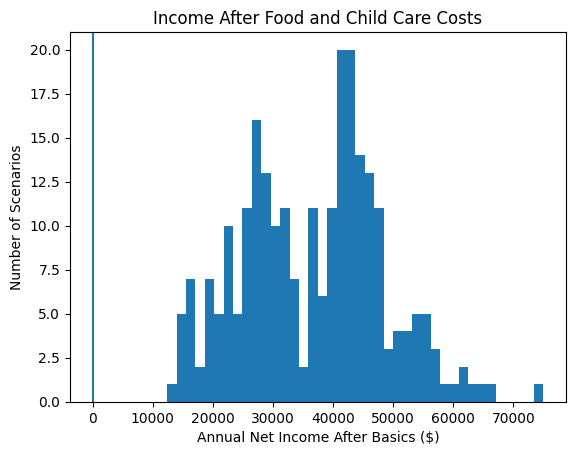

In [164]:
plt.figure()
plt.hist(affordability["net_after_necessities"], bins=40)
plt.axvline(0) # 'even' base line
plt.title("Income After Food and Child Care Costs")
plt.xlabel("Annual Net Income After Basics ($)")
plt.ylabel("Number of Scenarios")
plt.show()

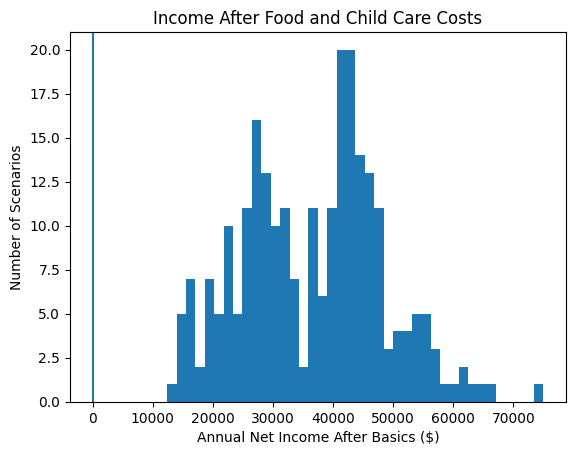

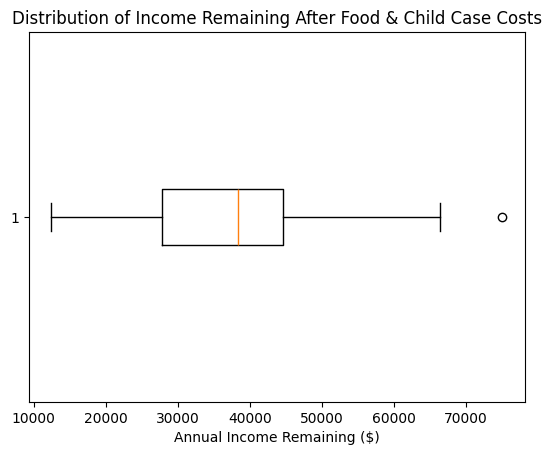

In [165]:
plt.figure()
plt.hist(affordability["net_after_necessities"], bins=40)
plt.axvline(0) # 'even' base line
plt.title("Income After Food and Child Care Costs")
plt.xlabel("Annual Net Income After Basics ($)")
plt.ylabel("Number of Scenarios")
plt.show()

plt.figure()
plt.boxplot(affordability["net_after_necessities"], vert=False)
plt.title("Distribution of Income Remaining After Food & Child Case Costs")
plt.xlabel("Annual Income Remaining ($)")
plt.show()

# Purpose: Show which degree paths struggle the most financially #

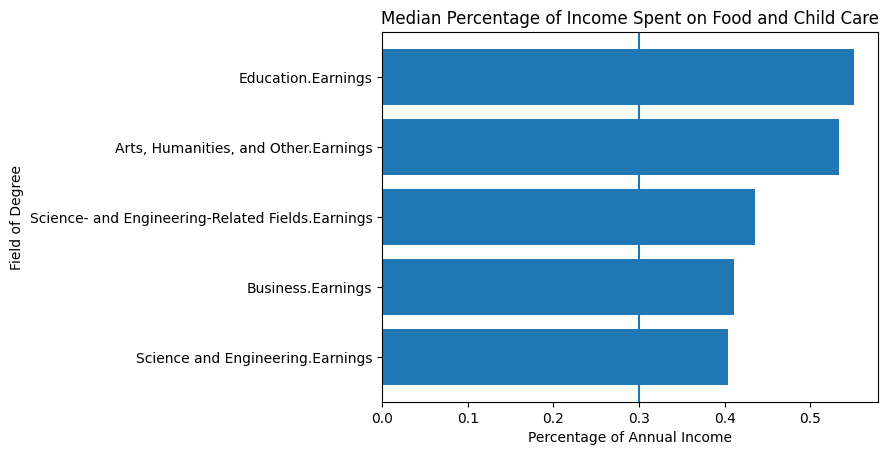

In [166]:
pct_spent_by_degree = (
    affordability
    .groupby("field_of_degree")["necessity_cost_pct"]
    .median()
    .sort_values()
)

plt.figure()
plt.barh(pct_spent_by_degree.index, pct_spent_by_degree.values)
plt.axvline(0.3) # affordability benchmark
plt.title("Median Percentage of Income Spent on Food and Child Care")
plt.xlabel("Percentage of Annual Income")
plt.ylabel("Field of Degree")
plt.show()

burden_by_degree = (
    affordability
    .groupby("field_of_degree")["necessity_cost_pct"]
    .median()
    .sort_values()
)

# Purpose: Show the correlation of rising earnings and rising child care costs. #

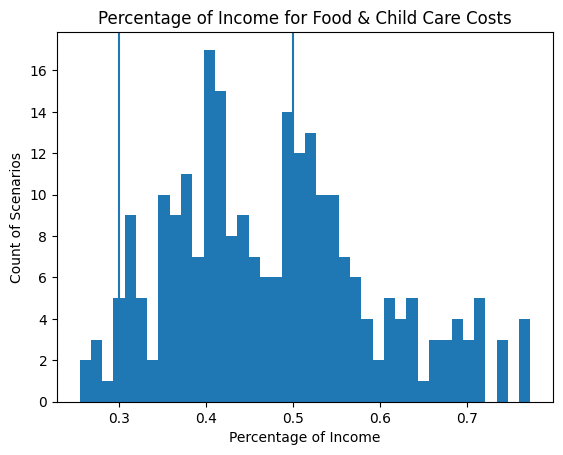

In [167]:
plt.figure()
plt.hist(affordability["necessity_cost_pct"], bins=40)
plt.axvline(0.3)
plt.axvline(0.5)
plt.title("Percentage of Income for Food & Child Care Costs")
plt.xlabel("Percentage of Income")
plt.ylabel("Count of Scenarios")
plt.show()

In [168]:
# affordability[["field_of_degree","is_negative","annual_earnings","net_after_necessities"]].head()
# affordability["is_negative"].value_counts(dropna=False)

In [169]:
# create sqlite db
conn = sqlite3.connect("affordability.db")

# write affordability table to sqlite
affordability.to_sql(
    "affordability",
    conn,
    if_exists="replace",
    index=False
)

conn

## SQL Query 1 - Average Cost Burden by Field of Degree ##

In [170]:
# SQL Query 1

query_1 = """
select
    field_of_degree,
    avg(necessity_cost_pct) as avg_cost_burden
    from affordability
    group by field_of_degree
    order by avg_cost_burden;
    """

pd.read_sql_query(query_1, conn)

,field_of_degree,avg_cost_burden
0,Science and Engineering.Earnings,0.415966
1,Business.Earnings,0.423941
2,Science- and Engineering-Related Fields.Earnings,0.446026
3,"Arts, Humanities, and Other.Earnings",0.545405
4,Education.Earnings,0.567626


## SQL Query 2 - States with Highest Child Care Burden ##

In [171]:
# SQL Query 2

query_2 = """
select
    State,
    avg(annual_child_care_cost_two_children) as avg_child_care_cost_two_children
from affordability
group by State
order by avg_child_care_cost_two_children desc
limit 10;
"""

pd.read_sql_query(query_2, conn)

,State,avg_child_care_cost_two_children
0,Massachusetts,50657.0
1,District of Columbia,50280.0
2,Maryland,47915.0
3,Hawaii,42967.0
4,Washington,40584.0
5,New Jersey,39661.0
6,New York,39100.0
7,Illinois,38543.0
8,Minnesota,38463.0
9,Colorado,38457.0


## SQL Query 3 - Fields of Degree with High Cost Burdens ##

In [172]:
# SQL Query 3

query_3 = """
select
    field_of_degree,
    avg(necessity_cost_pct) as avg_cost_burden
from affordability
group by field_of_degree
having avg_cost_burden > 0.4
order by avg_cost_burden desc;
"""

pd.read_sql_query(query_3, conn)

,field_of_degree,avg_cost_burden
0,Education.Earnings,0.567626
1,"Arts, Humanities, and Other.Earnings",0.545405
2,Science- and Engineering-Related Fields.Earnings,0.446026
3,Business.Earnings,0.423941
4,Science and Engineering.Earnings,0.415966
